In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
df=pd.read_csv('spam.csv', encoding='ISO-8859-1')
df=df[['v1','v2']]
df.columns=['label', 'message']

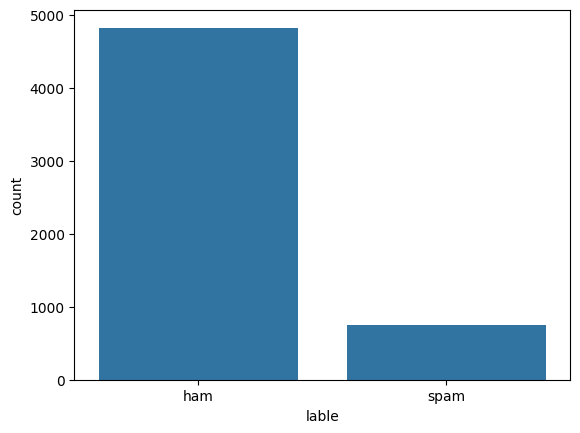

In [4]:
sns.countplot(x='label', data=df)
plt.xlabel("lable")
plt.ylabel("count")
plt.show()

In [21]:
# Convert text data to numerical data using CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(df['message']) # Transform messages to feature vector
# Encode labels ('ham' as 0, 'spam' as 1)
y = df['label'].map({'ham': 0, 'spam': 1})


In [22]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.naive_bayes import MultinomialNB

model=MultinomialNB()
model.fit(x_train, y_train)

MultinomialNB()

In [24]:
y_pred=model.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9785
[[952  13]
 [ 11 139]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115

